#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 12

### Wednesday, March 4, 2026: Chapter 6.3.1 - 6.3.4
- Nonlinear equations part 1

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Relaxation Method - 2 variable (25  points)

Use the relaxation method to solve for x and y in the following nonlinear equations: 

$$ 3x - \frac{1}{y} = -1 $$
$$2x^2 - y = 0$$

To do this: 
1) First solve the first equation for $x$ and the second equation for $y$. Put this in a markdown cell. 

2) Make an initial guess for $x$ and $y$ by thinking about one of the equations and determine number of iterations. Explain reasoning in markdown or commenting 

3) Apply the relaxation method (check class notebook) via a user-defined function `relax_method(N,x,y)`. Call on your function and see if it works! 

4) If it doesn't converge, try solving the inverse equations for $x$ and $y$ and try calling your relaxation method function again. 

*You must clearly comment your code and include a markdown cell explaining your process*

##### Part 1

First equation solved for x: $x = (-1 + \frac{1}{y})/3$

Second equation solved for y: $y = 2x^2$

In [2]:
# part 2
# initial guess by considering the first equation
y = 2.0
x = 0.75
N = 50

# The second equation can be solved analytically for y=2 and x=1, but this solution doesn't hold up for the first equation. 
# I decreased the value of x to be closer to the result given for the first equation when y=2.
# I set the number of iterations to be 50, as I think I'm pretty close and it's not going to be very time consuming.


In [3]:
# part 3
# equation for x
def f(x,y):
    return (-1 + 1/y)/3

# equation for y
def g(x,y):
    return 2*x**2

# define relaxation method function
def relax_method(N,x,y):
    for k in range(N):
        x,y = f(x,y), g(x,y)
        print(x,y)
    return x,y

answer = relax_method(N,x,y)
print("Solution for x:", answer[0])
print("Solution for y:", answer[1])

-0.16666666666666666 1.125
-0.037037037037037056 0.05555555555555555
5.666666666666667 0.0027434842249657093
121.16666666666653 64.22222222222223
-0.3281430219146482 29362.722222222157
-0.3333219810707328 0.2153556856625546
1.2144936130870196 0.22220708612983592
1.1667688422496998 2.9499894724583267
-0.2203385798111944 2.7226990624894096
-0.21090579886003716 0.09709817950642817
3.0996180878749886 0.0889625119855809
3.4135632626998387 19.215264581363602
-0.315986013866464 23.304828296907935
-0.31903014563820836 0.1996943219184344
1.3358845499346952 0.20356046765187288
1.3041817361613817 3.5691750615084463
-0.23994107109096072 3.4017800018738313
-0.23534541725712602 0.11514343519255493
2.561606641107227 0.1107749308478615
2.67577108029193 13.1236571675293
-0.30793390929488235 14.319501748253286
-0.3100550559746959 0.18964658498725764
1.424322009396566 0.1922682754709436
1.400355349923765 4.057386372902943
-0.25117863996730744 3.921990212120221
-0.24834247019878872 0.1261814183516525
2.30

The Relaxation Method takes initial guesses for unknown values (determined in part 1) and plugs the value into the right hand side of the equation. If the resulting value from the right hand side is not the same value as what was inputted, the left hand value is then taken and plugged into the right hand size. This process continues until the solution 'relaxes' into a value.

When working with two variables, this process simply runs in parallel


This is not converging! Time to try solving for the inverse equations.

Solving the inverse equations gives $x = \left(\frac{1}{y} + 1 \right) \frac{1}{3}$ and $y = \sqrt{\frac{1}{2} x}$

In [4]:
# part 4
# initial guess by considering the first equation
y = 2.0
x = 0.75
N = 50

# new equation for x
def f(x,y):
    return (1/y + 1) * (1/3)

# new equation for y
def g(x,y):
    #return 2*x**2
    return math.sqrt(0.5*y)

# call relax func defined in the cell above
ans = relax_method(N,x,y)
print("Solution for x:", ans[0])
print("Solution for y:", ans[1])

0.5 1.0
0.6666666666666666 0.7071067811865476
0.8047378541243649 0.5946035575013605
0.8939309435024764 0.5452538663326288
0.9446693621364475 0.5221368912137069
0.9717355204657158 0.5109485743270583
0.9857147080584667 0.5054446430258502
0.9928186754626502 0.5027149505564014
0.9963996156557555 0.5013556375251013
0.9981973707236467 0.5006773599460541
0.9990980752606468 0.5003385653465332
0.9995488850017671 0.5001692540263412
0.999774404330829 0.5000846198526511
0.999887192621286 0.5000423081363471
0.999943593924409 0.5000211536206979
0.9999717963656207 0.5000105766984824
0.9999858980336613 0.5000052883212749
0.9999929489795429 0.5000026441536459
0.9999964744804495 0.5000013220750751
0.9999982372378942 0.5000006610371006
0.9999991186183644 0.5000003305184411
0.9999995593090365 0.5000001652591932
0.9999997796544818 0.5000000826295898
0.9999998898272318 0.5000000413147933
0.9999999449136135 0.5000000206573962
0.9999999724568062 0.500000010328698
0.9999999862284029 0.500000005164349
0.9999999

I redefined the functions used within the relaxation method to follow the inverse equations I found above. Hopefully this will avoid any mathematical issues and result in converged solutions.

The new equations used required me to import math above.

After calling the relax_method() function, the solutions converged to x = 1 and y = 0.5.

## Binary Search (25 pts)

Use the binary search method to find the roots of $f(x) = 5e^{-x} +x -5$. 

To do this: 
1) Start by defining two functions: `f(x)` which returns the given function in the problem and `binary_solve(f,x1,x2,accuracy)` which applies the binary search method for a given function $f(x)$ based on two initial values $x_1, x_2$, and continues to iterate until a given accuracy is achieved. 

2) Call the function and analyze the results. [Use a graph to estimate the interval that returns a non-zero $x$.] 

3) Plot this point as a magenta star on the graph from step 2 to see if it agrees. 


*You must clearly comment your code and include a markdown cell explaining your process*

In [5]:
# part 1
# defining the given function
def f(x):
    return 5*math.exp(-x) + x -5

# defining the binary search method
def binary_solve(f, x1, x2, accuracy):
    f1 = f(x1)
    f2 = f(x2)

    # check if the signs are the same or opposite
    if f1 * f2 < 0:
        # accurate enough?
        while np.abs(x2 - x1) > accuracy:
            xp = 0.5*(x2+x1)
            fp = f(xp)
            # depends on the sign
            if fp*f1 > 0:
                x1, f1 = xp, fp
            else:
                x2, f2 = xp, fp
        result = 0.5 * (x1 + x2)
    else:
        # astronomy easter egg, I suppose
        result = -999.99
    
    return result


I first defined the given function and imported numpy above to be used within the following binary_solve() function.

The binary_solve() function first checks the previously defined function for values $x_1$ and $x_2$ to ensure $f(x_1)$ and $f(x_2)$ have opposite signs and are therefore on either side of the solution. The function also includes a target accuracy to establish a stopping point for the iterations.

The main purpose of this function is to calculate the midpoint $x'$ between $x_1$ and $x_2$ and, depending on the sign of $f(x')$, update the initial point with the same sign to be $x'$. 

If the distance between the two points being tested is greater than the target accuracy, the process is repeated. Otherwise it finds the midpoint one more time and returns it as the solution.


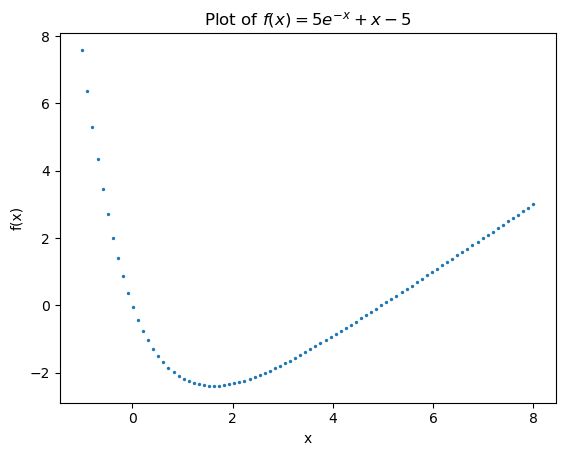

Non-zero solution to f(x): 4.965114229358733


In [10]:
# part 2
# plotting
# constants to control scale
x_scale = -1.0
y_scale = 8.0

# make an array of x-values
x_vals = np.linspace(x_scale, y_scale, 90)

# empty array to fill
func_ans = np.zeros(len(x_vals))

# fill the empty array
for i in range(len(x_vals)):
    func_ans[i] = f(x_vals[i])

# actual plotting
plt.scatter(x_vals, func_ans, s=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of $f(x) = 5e^{-x} +x -5$")
plt.show()

# solving for the non-zero solution
# initial guesses & accuracy
x1 = 3.0
x2 = 6.0
target = 1e-8

# call function
answer = binary_solve(f, x1, x2, target)
print("Non-zero solution to f(x):", answer)


The graph is meant to help us determine potential solutions and establish functional bounds for $x_1$ and $x_2$.

To make the plot, I imported matplotlib.pyplot above and created an array of x-values and an array of zeros to be filled from calculating $f(x)$. I then used the scatter() function with the created arrays. 

There appear to be solutions (where the function intersects with zero) around x = 0 and x = 5. Because I am looking for the non-zero solution, I was able to use the plot to change bounds of the binary_solve() function accordingly.

Labeled the plot for clarity.

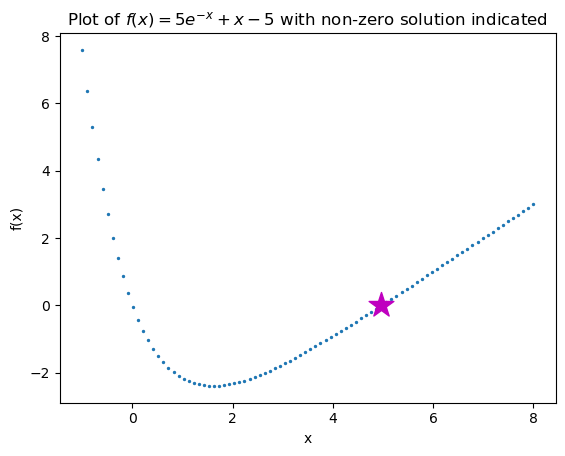

In [12]:
# part 3
mag_star_x = binary_solve(f, x1, x2, target)
mag_star_y = f(mag_star_x)

# old plot
plt.scatter(x_vals, func_ans, s=2)

# adding magenta star
plt.scatter(mag_star_x, mag_star_y, c="m", marker="*", s=350)

# labels
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of $f(x) = 5e^{-x} +x -5$ with non-zero solution indicated")

plt.show()


To highlight the location of the non-zero solution on the plot, I first found the x-value and the corresponding f(x) value. 

I then essentially stacked another scatter plot on top of the first showing the f(x) function with only the point of the non-zero solution. I was then able to specify the appearance and labels of the plot to be a magenta star.

## Energy of an electron in a square potential well

Consider a square potential well of width $w$, with walls of height $V$: 

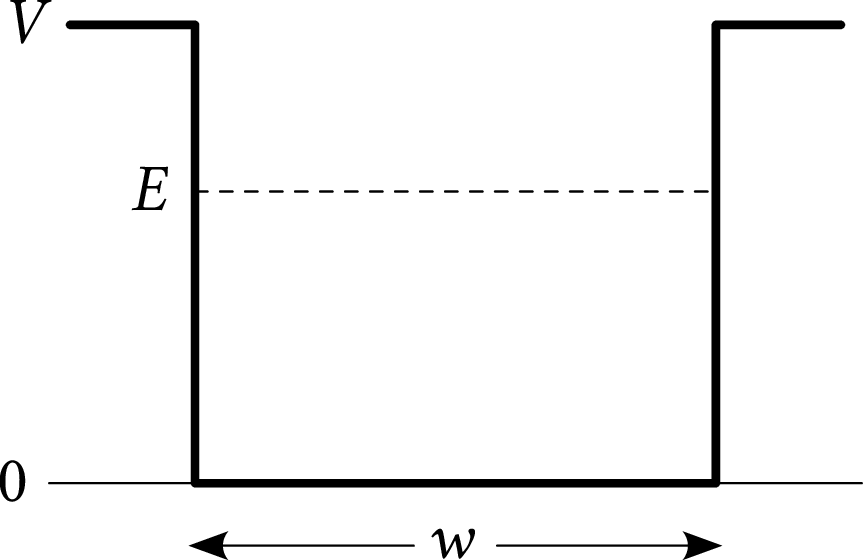

Using Schrödinger's equation, it can be shown that the allowed energies $E$ of a single quantum particle of mass $m$ trapped in the well are solutions of 
$$ \tan{\sqrt{w^2mE/2\hbar^2}} = \begin{cases} 
\sqrt{(V-E)/E} & \text{ for the even numbered states} \\
-\sqrt{E/(V-E)} & \text{ for the odd numbered states} 
\end{cases}
$$

where the states are labeled with integers starting from 0 and working upward, the ground state being state 0, the first excited state being state 1, and so forth. 

a) For an electron of (mass $9.1094 \times 10^{-31}$ kg) in a well with $V = 20 \text{ eV}$ and $w = 1 \text{ nm}$, write a Python program to plot the three quantities 
$$y_1 = \tan{\sqrt{w^2mE/2\hbar^2}} \hspace{0.2in} y_2 = \sqrt{\frac{V-E}{E}} \hspace{0.2in} y_3 = -\sqrt{\frac{E}{V-E}}, $$

on the same graph, as a function of $E$ from $E = 0$ to $E = 20 \text{ eV}$. **Hint** You may find it useful to define functions to calculate $y_1$, $y_2$, and $y_3$. 

b) From your plot make approximate estimates of the energies of the first six energy levels of the particle. 

c) Write a program to calculate the values of the first six energy levels in electron volts to an accuracy of $0.001 \text{ eV}$ using binary search. 

*hint, remember that energies need to be converted to joules in the $y_1$ equation above*

*You must clearly comment your code and include a markdown cell explaining your process*

In [ ]:
#a) no time :(

In [ ]:
#b) no time :(

In [ ]:
#c) no time :(